# Relatório Parcial — Algoritmo Genético para CVRP

**Disciplina:** Inteligência Artificial  
**Grupo 8:** Erik Morbach, Gabriel Farias, Lucas Escopelli  
**Problema:** Capacitated Vehicle Routing Problem (CVRP)

---


## 1. Descrição do Problema

O **Capacitated Vehicle Routing Problem (CVRP)** consiste em, dado um conjunto de cidades (nós) com demandas individuais e um depósito central, determinar um conjunto de rotas para uma frota de veículos com capacidade limitada, de forma que:

- Cada cidade seja visitada exatamente uma vez;
- A demanda total de cada rota não exceda a capacidade do veículo;
- O depósito seja o ponto de partida e chegada de cada rota.

**Objetivo (prioridade):**
1. **Minimizar** o número de veículos utilizados;
2. **Minimizar** a soma total das distâncias percorridas.

O problema é NP-difícil, tornando algoritmos exatos inviáveis para instâncias grandes — o que justifica o uso de meta-heurísticas como Algoritmos Genéticos.

Exemplo: Uma distribuidora tem um depósito de itens de decoração em São Sebastião do Caí e precisa fornecer itens para uma loja com filiais em cidades como São Leopoldo, Porto Alegre, Bom Princípio e Montenegro. Cada uma dessas cidades tem populações diferentes, o que acarreta também em uma demanda diferente de produtos para serem enviados. Não só isso, essas cidades ficam em direções diferentes e tem distâncias diferentes, o que dificulta o uso de um mesmo caminhão para toda a rota.


## 2. Análise da Instância

### 2.1 Leitura e Visualização dos Dados

O código a seguir lê uma instância no formato `.vrp` e exibe as posições e demandas de cada cidade:


CAP: 8000
Nodes: 33 {1: (292, 495), 2: (298, 427), 3: (309, 445), 4: (307, 464), 5: (336, 475), 6: (320, 439), 7: (321, 437), 8: (322, 437), 9: (323, 433), 10: (324, 433), 11: (323, 429), 12: (314, 435), 13: (311, 442), 14: (304, 427), 15: (293, 421), 16: (296, 418), 17: (261, 384), 18: (297, 410), 19: (315, 407), 20: (314, 406), 21: (321, 391), 22: (321, 398), 23: (314, 394), 24: (313, 378), 25: (304, 382), 26: (295, 402), 27: (283, 406), 28: (279, 399), 29: (271, 401), 30: (264, 414), 31: (277, 439), 32: (290, 434), 33: (319, 433)}
NodeCap: {1: 0, 2: 700, 3: 400, 4: 400, 5: 1200, 6: 40, 7: 80, 8: 2000, 9: 900, 10: 600, 11: 750, 12: 1500, 13: 150, 14: 250, 15: 1600, 16: 450, 17: 700, 18: 550, 19: 650, 20: 200, 21: 400, 22: 300, 23: 1300, 24: 700, 25: 750, 26: 1400, 27: 4000, 28: 600, 29: 1000, 30: 500, 31: 2500, 32: 1700, 33: 1100}
totalSum: 29370
minimalNumberOfTrucks: 3.67125


Matplotlib is building the font cache; this may take a moment.


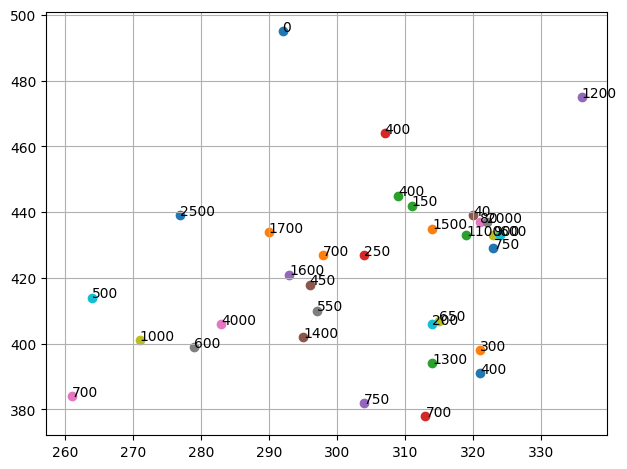

In [9]:
CAP = 0
Nodes = {}
NodeCap = {}
totalSum = 0
filePath = "/Users/i752466/Faculdade/AI/eil33.vrp"

state = 0
with open(filePath) as file:
    lines = file.readlines()
    for line in lines:
        if "CAPACITY" in line:
            CAP = int(line.replace('\n', '').split(':')[1])
            continue
        if "NODE_COORD_SECTION" in line:
            state = 1
            continue
        if "DEMAND_SECTION" in line:
            state = 2
            continue
        if state == 1:
            id, x, y = list(map(int, line.split(' ')))
            Nodes[id] = (x, y)
            continue
        if state == 2:
            id, cap = list(map(int, line.split(' ')))
            NodeCap[id] = cap
            totalSum += cap
            continue

print("CAP:", CAP)
print("Nodes:", len(Nodes.keys()), Nodes)
print("NodeCap:", NodeCap)
print("totalSum:", totalSum)
print("minimalNumberOfTrucks:", totalSum / CAP)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for id, node in Nodes.items():
    ax.scatter(node[0], node[1])
    ax.annotate(NodeCap[id], xy=node)

ax.grid(True)
fig.tight_layout()
plt.show()


**Saída para a instância `eil33.vrp`:**

```
CAP: 8000
Nodes: 33 {1: (292, 495), 2: (298, 427), ..., 33: (319, 433)}
NodeCap: {1: 0, 2: 700, 3: 400, ..., 33: 1100}
totalSum: 29370
minimalNumberOfTrucks: 3.67125
```

### 2.2 Características da Instância

| Parâmetro | Valor |
|---|---|
| Número de cidades (incluindo depósito) | 33 |
| Capacidade de cada veículo | 8.000 |
| Soma total das demandas | 29.370 |
| Número mínimo teórico de veículos | ⌈3,67⌉ = **4** |

> **Nota:** O nó 1 é o depósito (demanda = 0). O número mínimo de veículos é calculado dividindo a soma total das demandas pela capacidade, arredondando para cima. Esse valor constitui o *lower bound* para o primeiro objetivo de otimização.


## 3. Modelagem

### 3.1 Representação dos Indivíduos

Cada **indivíduo** representa uma solução completa do CVRP — isto é, um conjunto de rotas que atende todas as cidades respeitando as restrições de capacidade.

#### Estrutura adotada: Lista de Rotas

Um indivíduo é representado como uma **lista de rotas**, onde cada rota é uma lista ordenada de cidades:

```
Indivíduo = [
    Rota_1: [c3, c7, c12],
    Rota_2: [c2, c15, c8],
    Rota_3: [c5, c11, c19],
    Rota_4: [c1, c6,  c20],
    Conjunto: [bla, bla, Pivo, bla]
]
```

A definição de cada rota é feita por meio de uma algoritmo de programação dinâmica que escolhe de forma ótima em que pontos uma rota deve iniciar. A ordem das cidades dentro de cada rota define a sequência de visitas — sub-problema análogo ao TSP.

#### Justificativa da Representação

Esta estrutura foi escolhida porque:
- Facilita o cálculo da **função objetivo** (distância total e contagem de rotas);
- Permite a aplicação direta dos **operadores genéticos** sobre as rotas individualmente (mutação intra-rota) ou entre rotas (cruzamento inter-rota).

#### Estratégia de Pivô (Redução do Espaço de Busca)

Para melhorar a eficiência da busca, adotamos uma heurística de **seleção de pivôs** para inicializar a partição de cidades em grupos (pré-rotas). Um pivô é um nó que serve como "âncora" de uma rota, selecionado com base em dois critérios:

1. **Distância média razoável** em relação às demais cidades não atribuídas;
2. **Baixa conectividade** com nós já incluídos em outras rotas (máxima separação geográfica entre rotas).

Essa estratégia reduz o problema inicial de particionamento, permitindo que o algoritmo genético foque na otimização das sequências internas de cada rota.


### 3.3 Operadores Genéticos

#### 3.3.1 Seleção

Utilizamos **seleção por torneio** com tamanho $k$: sorteiam-se $k$ indivíduos aleatoriamente da população e o de menor custo é selecionado. Isso equilibra pressão seletiva e diversidade.

```
Torneio de tamanho k:
  candidatos = amostra aleatória de k indivíduos
  retorna argmin fitness(candidatos)
```


#### 3.3.2 Cruzamento (Crossover)

Utilizamos um operador de **cruzamento baseado em rotas (Route-Based Crossover — RBX)**:

1. Seleciona-se aleatoriamente um subconjunto de rotas do **Pai 1**;
2. As cidades já presentes nessas rotas são marcadas como "atribuídas";
3. As cidades restantes são extraídas do **Pai 2** na ordem em que aparecem, preservando a estrutura de rotas do Pai 2 para as cidades não atribuídas;
4. O filho resultante combina as rotas herdadas do Pai 1 com as rotas remontadas do Pai 2.

Essa abordagem preserva sub-rotas válidas dos pais e tende a herdar boas soluções locais (ordem de visita eficiente dentro das rotas).

```
Pai1: [[c3, c7], [c2, c5], [c1, c8]]
Pai2: [[c7, c1], [c3, c8], [c2, c5]]

Seleciona rotas do Pai1: [[c3, c7]]  → cidades atribuídas: {c3, c7}
Completa com Pai2 (cidades não atribuídas: c1, c2, c5, c8):
  Pai2 fornece: [c1], [c8], [c2, c5]
  
Filho: [c3, c7, c1, c8, c2, c5]

Após a execução da rotina de agrupar em rotas:

Filho: [[c3, c7], [c1, c8], [c2, c5]]
```


#### 3.3.3 Mutação

Implementamos dois tipos de mutação, aplicados com probabilidades independentes:

**a) Mutação intra-rota:**  
Inverte a posição de duas cidades dentro da rota escolhida de forma uniforme:

```
Rota original: [c2, c5, c8, c3]
Cidades trocadas [c5 e c3]
Rota mutada:   [c2, c3, c8, c5]
```

**b) Mutação inter-rota:**  
Troca cidades entre duas rotas escolhidas aleatóriamente. 

```
Antes: Rota_A = [c3, c7], Rota_B = [c2, c5]
Move c7 de A para B:
Depois: Rota_A = [c3, c5], Rota_B = [c2, c7]
```


## 4. Estrutura do Algoritmo Genético

```
ALGORITMO GENÉTICO — CVRP

Entrada: instância CVRP, parâmetros (pop_size, n_gen, p_cross, p_mut)
Saída: melhor solução encontrada

1. INICIALIZAÇÃO
   - Processa a população inicial usando heurística de pivôs;
   - Cada indivíduo: lista de rotas geradas por inserção gulosa a partir dos pivôs

2. AVALIAÇÃO
   - Calcular fitness(s) para cada indivíduo s da população

3. LOOP EVOLUTIVO (repetir por n_gen gerações):
   a. SELEÇÃO: torneio de tamanho k para selecionar pais
   b. CRUZAMENTO: aplicar com probabilidade p_cross
   c. MUTAÇÃO: aplicar as duas mutações com probabilidades diferentes
   d. AVALIAÇÃO: calcular fitness dos filhos
   e. SUBSTITUIÇÃO: elitismo (mantém o melhor) + substituição da população

4. RETORNAR melhor indivíduo encontrado
```

---

## 5. Considerações Finais

A modelagem apresentada define os elementos centrais do algoritmo genético para o CVRP:

- **Representação** como lista de rotas, adequada à natureza do problema e compatível com os operadores definidos;
- **Função de avaliação** que prioriza explicitamente a minimização da distância;
- **Operadores** que combinam exploração global (cruzamento RBX, relocação inter-rota) com intensificação local (2-opt intra-rota);
- **Heurística de pivôs** como estratégia de inicialização para gerar soluções viáveis de qualidade.

As próximas etapas incluem a implementação completa do loop evolutivo, geração da população inicial via pivôs e experimentação com diferentes instâncias e configurações de parâmetros.
